In [49]:
import sys
import os
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
from accelerate.test_utils.testing import get_backend
from core.callbacks import WandBCallback
from lightning.pytorch.loggers import WandbLogger
from lightning import Trainer
from core.data import FullBatchDataModule
from core.estimators import BiasWithMSE, BiasWithAutodiffLoss #, BiasWithRidgeKernelMSE
from core.utils import rbf_kernel_torch
from core.models import KernelRegression
from functools import partial
from lightning.pytorch.callbacks import EarlyStopping
device, n_devices, _ = get_backend()
# device = "cpu"
# n_devices = 1

torch.set_float32_matmul_precision("highest")

## Kernel Regression

In [2]:
# sinusoidal data
torch.manual_seed(56)
N = 200
p = 1 # input dimension / number of features
X = torch.randn(N, p)
betas = torch.ones(p)#3 * torch.randn(p)
y = torch.sin(X @ betas) + 0.1 * torch.randn(N)
dm_sin = FullBatchDataModule(X, y, num_workers=3)

In [3]:
eta = 1e-4 # learning rate
lambda_ = 0.1 # regularization parameter
gamma = 10. # width of the RBF kernel
# compute RBF kernel
pre_comp_K = rbf_kernel_torch(X, X, gamma=gamma)
# find max eigenvalue
eigenvalues = torch.linalg.eigvalsh(pre_comp_K @ pre_comp_K / N + lambda_ * pre_comp_K)
max_eigenvalue = eigenvalues.max().item()
min_eigenvalue = eigenvalues.min().item()
print(f"Max eigenvalue of C: {max_eigenvalue:.10f}")
print(f"Min eigenvalue of C: {min_eigenvalue:.10f}")
# learning rate condition
print(f"Max learning rate: {1. / max_eigenvalue:.10f}")
assert eta < 1. / max_eigenvalue, "Learning rate is too high!"

Max eigenvalue of C: 13.4426345825
Min eigenvalue of C: -0.0000006029
Max learning rate: 0.0743901795


In [4]:
# Regression with RBF kernel
rbf_kernel_reg = KernelRegression(
    kernel_function=partial(rbf_kernel_torch, gamma=gamma),
    n_train_samples=N, 
    fit_intercept=False,
    ridge_lambda=lambda_,
    init_zeros=True,
    lr=eta  # no mismatch in lr for our derivation of kernel regression
)
# store the initial alphas
wandb_logger = WandbLogger(
    project="inductive-bias", name="kernel-regression", log_model=False
)

rbf_trainer = Trainer(
    max_epochs=500,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    logger=wandb_logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=150, mode="min"),
    ],
    accelerator=device,
    devices=n_devices,
    # detect_anomaly=True,
)

rbf_trainer.fit(rbf_kernel_reg, dm_sin)
t = rbf_trainer.current_epoch

/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/jrudoler/.cache/pypoetry/virtualenvs/i ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type               | Params | Mode 
-------------------------------------------------------------
0 | kernel_linear | Linear             | 200    | train
1 | loss_func     | KernelRidgeMSELoss | 0      | train
-------------------------------------------------------------
200       Trainable params
0         Non-trainable params
200       Total params
0.001     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=500` reached.


epoch,▁▁▁▁▁▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇███
train/loss,██▇▆▆▅▅▄▄▄▄▃▃▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇████
epoch,499
train/loss,0.28752
trainer/global_step,499


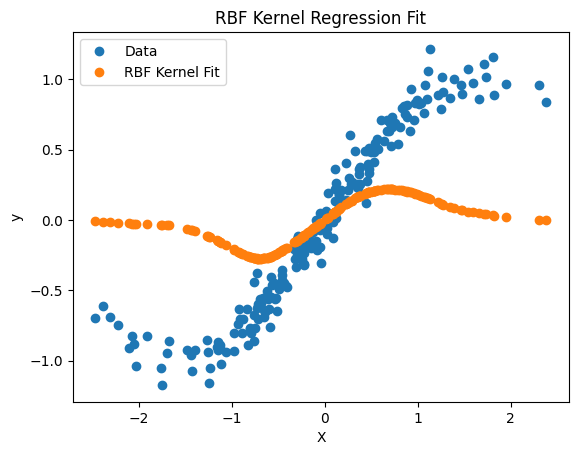

In [5]:
# plot the data and the RBF kernel regression fit
import matplotlib.pyplot as plt

plt.plot(X[:, 0], y, 'o', label='Data')
plt.plot(X[:, 0], rbf_kernel_reg(X).detach().numpy(), 'o', label='RBF Kernel Fit')
plt.title('RBF Kernel Regression Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

In [6]:
K = rbf_kernel_torch(X, X, gamma=gamma)
assert torch.isfinite(K).all()
alpha = rbf_kernel_reg.kernel_linear.weight.detach().view(-1)
print(f"RBF Kernel Regression alphas: \n{alpha}")

RBF Kernel Regression alphas: 
tensor([-2.2022e-03, -6.4331e-03,  1.9609e-03,  4.3229e-03, -7.4773e-03,
        -2.7040e-03, -7.3917e-03, -7.9127e-03, -1.4467e-03, -2.6789e-03,
         7.7299e-03, -1.9017e-03,  4.1142e-03,  4.8105e-03,  5.1345e-03,
        -7.9209e-03, -6.5845e-03, -6.3240e-03, -6.2495e-03,  1.5282e-03,
         1.8523e-03, -5.6587e-03, -2.0694e-03, -7.5072e-03, -5.7185e-03,
         7.4473e-03, -6.6255e-03, -7.9208e-03, -7.1221e-03,  6.9059e-03,
        -3.7593e-03,  1.2669e-03, -6.6337e-03, -3.3606e-03, -3.2843e-03,
        -7.0832e-03,  5.8773e-03,  1.7931e-03,  7.1831e-03,  7.6954e-03,
        -8.1768e-04,  9.5284e-04,  7.6919e-03, -5.4244e-03,  5.2916e-03,
        -7.9179e-03,  4.3780e-03,  6.4249e-03, -2.7513e-03, -4.7601e-03,
        -3.5912e-03,  5.4745e-03,  6.3108e-03,  4.1650e-03,  4.2838e-03,
         4.2639e-03,  1.8285e-03, -7.7460e-03, -5.0727e-03, -6.7243e-03,
        -3.7348e-03,  3.4160e-03, -7.6105e-04,  5.7790e-03, -3.5508e-03,
        -7.2216e-03,

In [7]:
# from core.bias import ImplicitBiasKRR
# Estimate the quadratic form using the estimated Q from matrix ridge bias
from core.models import KernelRidgeMSELoss
from core.bias import DiagMatrixRidgeBias, DiagMatrixBiasKRR

## .detach() is essential here to detach the predictive model from the graph
alpha_init = rbf_kernel_reg.init_weights.view(-1).detach().clone()

# Use vanilla MSE loss, additional regularization is handled by the bias model
rbf_estimator = BiasWithMSE(
    predictive_model=rbf_kernel_reg,
    bias_model=DiagMatrixBiasKRR(
        dim=N,
        alpha_init=alpha_init,
        t=t,
        K=K,
        eta=eta,
        lambda_=lambda_,
    ),
    grad_match_loss_fn=torch.nn.functional.mse_loss,
    lr=1e-2,
    optimizer_cls=torch.optim.Adam,
)

wandb_logger = WandbLogger(
    project="inductive-bias", name="kernel-bias", log_model=False
)
rbf_trainer = Trainer(
    max_epochs=1000,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    logger=wandb_logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=150, mode="min"),
    ],
    accelerator="gpu",
    devices=n_devices,
)
# kernel_dataloader = DataLoader(TensorDataset(X, y), batch_size=N, shuffle=True)
rbf_trainer.fit(rbf_estimator, dm_sin)

/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/jrudoler/.cache/pypoetry/virtualenvs/i ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type              | Params | Mode 
---------------------------------------------------------------
0 | predictive_model | KernelRegression  | 200    | train
1 | bias_model       | DiagMatrixBiasKRR | 200    | train
---------------------------------------------------------------
400       Trainable params
0         Non-trainable params
400       Total params
0.002     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1000` reached.


bias/Q_t,▁▁▁▁▁▂▂▂▃▃▄▄▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇██████████
bias/Q_t_grad,██▇▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇█████
train/loss,███▇▇▇▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇███
bias/Q_t,81.53811
bias/Q_t_grad,2e-05
epoch,999
train/loss,0.0001
trainer/global_step,999


In [50]:
from typing import Optional
def compute_kernel_ridge_Q_omega(K: torch.Tensor, eta: float, t: int, lambda_: float, alpha_init: torch.Tensor) -> torch.Tensor:
    """
    Compute the Q matrix for kernel ridge regression.
    """
    dim = K.shape[0]
    I = torch.eye(dim, device=K.device)
    C = (1. / dim) * (K @ K) + lambda_ * K
    A = I - 2 * eta * C
    A_t = torch.linalg.matrix_power(A, t)
    Q_t = C @ (torch.linalg.inv(I - A_t) - I)

    omega_t = (C + Q_t) @ A_t @ alpha_init 

    return Q_t, omega_t

def compute_alpha_closed_form(K: torch.Tensor, y: torch.Tensor, Q: torch.Tensor, omega: torch.Tensor, lambda_: float) -> torch.Tensor:
    """
    Compute the closed-form solution for alpha using the kernel matrix K.
    """
    n = K.shape[0]
    C = (1 / n) * K @ K + lambda_ * K
    rhs = omega + (1 / n) * K @ y
    lhs = C + Q
    alpha = torch.linalg.solve(lhs, rhs)
    return alpha

# Q_kernel_ridge, omega_kernel_ridge = compute_kernel_ridge_Q_omega(K, eta=eta, t=t, lambda_=lambda_, alpha_init=alpha_init)

In [9]:
Q_hat_kernel_ridge = torch.diag(rbf_estimator.bias_model.Q_t.detach())
print("estimated Q from kernel ridge bias:\n", Q_hat_kernel_ridge)
# now estimate the quadratic form using the estimated Q from kernel bias
print("theoretical Q from kernel ridge regression:\n", Q_kernel_ridge)

estimated Q from kernel ridge bias:
 tensor([[4.9581, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 6.8438, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 4.6197,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 5.0743, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.4987, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 6.6061]])
theoretical Q from kernel ridge regression:
 tensor([[ 6.6630e-02, -3.8863e-04,  7.2739e-03,  ...,  4.9822e-01,
         -2.8740e+00, -3.5806e-02],
        [-1.2774e-04, -7.9529e-01,  4.2023e-03,  ...,  4.0473e-02,
         -1.7452e-01,  3.8228e+00],
        [ 8.2293e-03,  7.9967e-03,  9.0682e-02,  ...,  2.3259e+00,
          1.2536e+00, -4.9299e-01],
        ...,
        [-3.5015e-02, -3.1200e-03, -1.8316e-01,  ..., -7.5856e+00,
          1.0078e+00,  1.8195e-01],
        [-1.3191e-01, -6.0482e-03, -7.2052e-02,  ..., -5.1836e-01,
          5.5344e+00,  3.733

In [12]:
# Compare the estimated Q from kernel bias with the one from kernel regression
theory_alpha = compute_alpha_closed_form(K, y, Q_kernel_ridge, torch.zeros(N), lambda_=lambda_)
estimated_alpha = compute_alpha_closed_form(K, y, Q_hat_kernel_ridge, torch.zeros(N), lambda_=lambda_)
print("theoretical alpha from Q bias:\n", theory_alpha[:25])
print("estimated alpha from Q bias:\n", estimated_alpha[:25])
print("ground truth alpha:\n", alpha[:25])

theoretical alpha from Q bias:
 tensor([ 0.0408,  0.8113,  0.1442, -0.1898, -0.0084, -0.4218,  0.3268, -0.9412,
        -0.0016, -0.9715, -0.4165, -0.0025,  0.1862,  0.0078, -0.2311,  0.5479,
        -0.3474,  0.1903, -0.5855,  0.0266,  0.1095,  0.2755,  0.0079, -0.2639,
         0.0301])
estimated alpha from Q bias:
 tensor([-0.0024, -0.0074,  0.0018,  0.0043, -0.0083, -0.0028, -0.0075, -0.0081,
        -0.0019, -0.0028,  0.0084, -0.0024,  0.0041,  0.0059,  0.0052, -0.0082,
        -0.0076, -0.0063, -0.0063,  0.0013,  0.0017, -0.0057, -0.0023, -0.0076,
        -0.0057])
ground truth alpha:
 tensor([-0.0022, -0.0064,  0.0020,  0.0043, -0.0075, -0.0027, -0.0074, -0.0079,
        -0.0014, -0.0027,  0.0077, -0.0019,  0.0041,  0.0048,  0.0051, -0.0079,
        -0.0066, -0.0063, -0.0062,  0.0015,  0.0019, -0.0057, -0.0021, -0.0075,
        -0.0057])


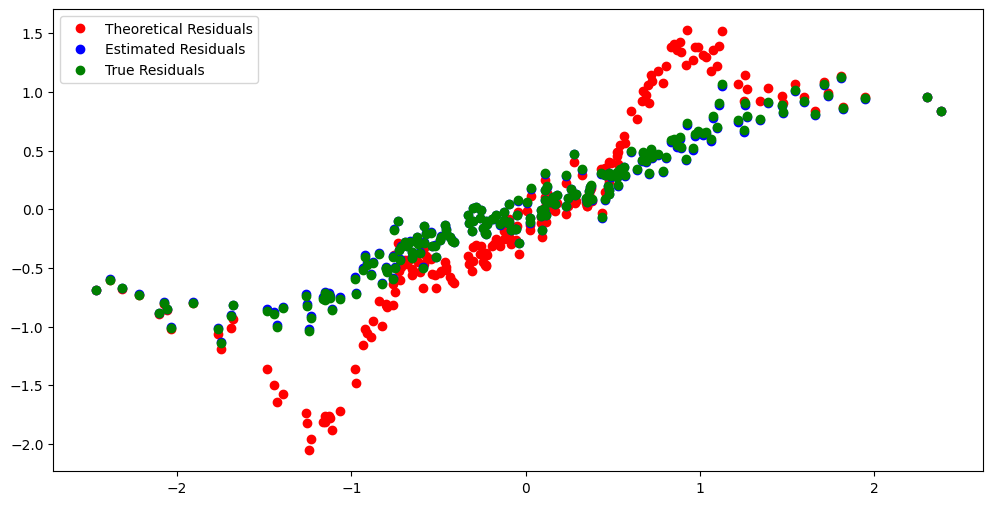

In [13]:
# predictions from the bias model
theory_resid = y - (theory_alpha @ K)
estimated_resid = y - (estimated_alpha @ K)
true_resid = y - (alpha @ K)
plt.figure(figsize=(12, 6))
plt.plot(X[:, 0], theory_resid, 'o', color="red", label='Theoretical Residuals')
plt.plot(X[:, 0], estimated_resid, 'o', color="blue", label='Estimated Residuals')
plt.plot(X[:, 0], true_resid, 'o', color="green", label='True Residuals')
plt.legend()

In [14]:
# compare RMSE
from sklearn.metrics import mean_squared_error
theory_rmse = mean_squared_error(y, theory_resid)
estimated_rmse = mean_squared_error(y, estimated_resid)
true_rmse = mean_squared_error(y, true_resid)
print(f"Theoretical RMSE: {theory_rmse:.4f}")
print(f"Estimated RMSE: {estimated_rmse:.4f}")
print(f"True RMSE: {true_rmse:.4f}")

Theoretical RMSE: 0.0963
Estimated RMSE: 0.0304
True RMSE: 0.0283


In [15]:
from core.utils import is_psd

print("Is the estimated Q positive semidefinite?", is_psd(Q_hat_kernel_ridge))
print("Is the theoretical Q positive semidefinite?", is_psd(Q_kernel_ridge))

Is the estimated Q positive semidefinite? False
Is the theoretical Q positive semidefinite? False


In [16]:
1/torch.linalg.eigvalsh(Q_kernel_ridge).max()

tensor(0.0142)

In [17]:
torch.linalg.matrix_power(K, 2)

tensor([[3.1715e+01, 8.7909e-02, 1.8454e+01,  ..., 8.1673e+00, 2.6624e+01,
         4.1347e-01],
        [8.7909e-02, 1.2044e+01, 1.1491e-03,  ..., 6.3111e-05, 7.7729e-03,
         1.2262e+01],
        [1.8454e+01, 1.1491e-03, 3.3785e+01,  ..., 2.7560e+01, 3.0964e+01,
         8.4177e-03],
        ...,
        [8.1673e+00, 6.3111e-05, 2.7560e+01,  ..., 3.1976e+01, 1.9693e+01,
         6.2944e-04],
        [2.6624e+01, 7.7729e-03, 3.0964e+01,  ..., 1.9693e+01, 3.3935e+01,
         4.6832e-02],
        [4.1347e-01, 1.2262e+01, 8.4177e-03,  ..., 6.2944e-04, 4.6832e-02,
         1.5186e+01]])

In [23]:
Q_hat_kernel_ridge

tensor([[4.9581, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 6.8438, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 4.6197,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 5.0743, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.4987, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 6.6061]])

In [25]:
Q_kernel_ridge

tensor([[ 6.6630e-02, -3.8863e-04,  7.2739e-03,  ...,  4.9822e-01,
         -2.8740e+00, -3.5806e-02],
        [-1.2774e-04, -7.9529e-01,  4.2023e-03,  ...,  4.0473e-02,
         -1.7452e-01,  3.8228e+00],
        [ 8.2293e-03,  7.9967e-03,  9.0682e-02,  ...,  2.3259e+00,
          1.2536e+00, -4.9299e-01],
        ...,
        [-3.5015e-02, -3.1200e-03, -1.8316e-01,  ..., -7.5856e+00,
          1.0078e+00,  1.8195e-01],
        [-1.3191e-01, -6.0482e-03, -7.2052e-02,  ..., -5.1836e-01,
          5.5344e+00,  3.7332e-01],
        [ 2.1920e-03, -5.5232e-01,  3.1603e-02,  ...,  2.8765e-01,
         -1.3056e+00,  1.5475e+01]])

In [31]:
rbf_estimator.bias_model.Q_t_exact

tensor([[ 2.9199e-01,  1.4801e-02,  4.4678e-02,  ...,  8.5938e-02,
         -7.9883e-01,  5.1074e-01],
        [ 1.5717e-02, -1.4160e-02,  7.9498e-03,  ...,  2.1423e-02,
         -7.0679e-02, -5.2578e+00],
        [ 3.4424e-02,  6.8550e-03,  1.2500e-01,  ..., -6.4062e-01,
         -4.8047e-01,  1.8024e-01],
        ...,
        [-2.3315e-02, -2.2659e-03, -1.6602e-02,  ..., -1.7852e+00,
         -1.7615e-01, -6.6406e-02],
        [-2.0117e-01, -1.1024e-02, -1.6797e-01,  ...,  1.1328e-01,
          1.0586e+00, -3.0615e-01],
        [-1.3208e-01,  1.2017e+00, -5.0552e-02,  ..., -1.5668e-01,
          4.7754e-01,  3.0844e+01]], device='cuda:0')

In [33]:
rbf_estimator.bias_model.omega_t_exact

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')

In [35]:
rbf_estimator.bias_model.t

500

In [37]:
K.shape[0]

200

In [51]:
import torch

def compare_Q_matrices(
    K: torch.Tensor,
    eta: float,
    t: int,
    lambda_: float,
    alpha_init: torch.Tensor,
    atol: float = 1e-6
) -> None:
    n = K.size(0)
    # 1) exact from the standalone function
    Q_func, _ = compute_kernel_ridge_Q_omega(K, eta, t, lambda_, alpha_init)

    # 2) exact from the class
    model = DiagMatrixBiasKRR(
        dim=n, t=t, K=K, alpha_init=alpha_init,
        eta=eta, lambda_=lambda_
    )
    # forward just to populate model.Q_t_exact
    _ = model(alpha_init)

    Q_cls = model.Q_t_exact
    print(n)
    print(model.dim)
    print(model.t)
    diff = (Q_func - Q_cls).abs().max().item()

    print(f"max|Q_func – Q_cls| = {diff:.3e}")
    if diff < atol:
        print("✅ They match to within tolerance")
    else:
        print("❌ Mismatch—check your λ, t, dtype or device")

# Example usage:
torch.manual_seed(0)
n = 5
K = torch.rand(n, n)
K = K @ K.t()  # make it SPD
α0 = torch.randn(n)
compare_Q_matrices(K, eta=1e-2, t=10, lambda_=1e-3, alpha_init=α0)

5
5
10
max|Q_func – Q_cls| = 0.000e+00
✅ They match to within tolerance
